In [ ]:
pip install catboost

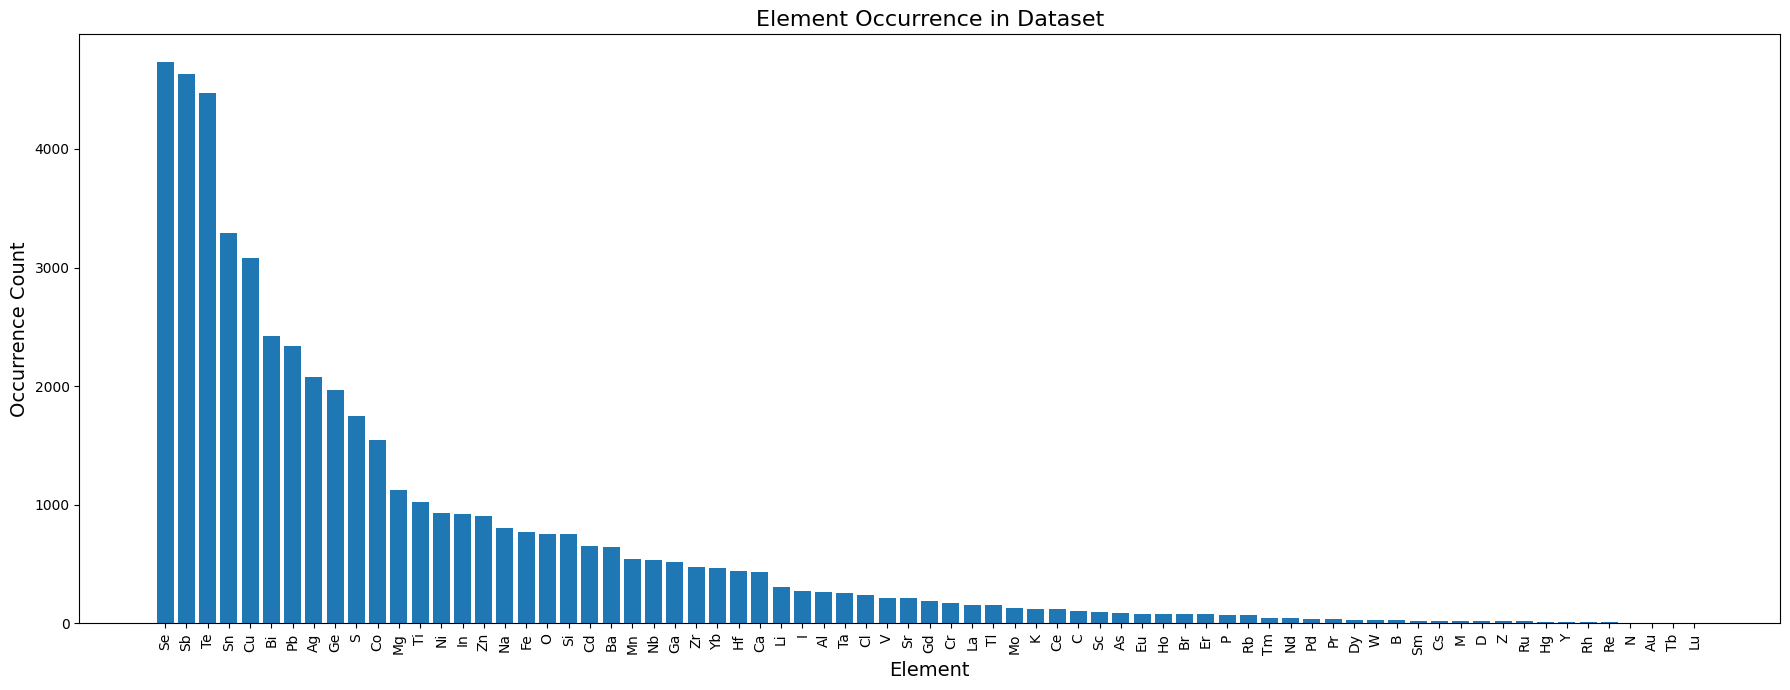

In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv("/content/combined_all_data_less_than_40.csv")

pattern = re.compile(r'([A-Z][a-z]?)')

all_elements = []

for formula in df["Formula"]:
    elements = pattern.findall(str(formula))
    all_elements.extend(elements)

element_counts = Counter(all_elements)

element_df = pd.DataFrame({
    "Element": list(element_counts.keys()),
    "Count": list(element_counts.values())
})

element_df = element_df.sort_values(
    by="Count",
    ascending=False
).reset_index(drop=True)

element_df.to_csv("count_element.csv", index=False)

# bar chart
plt.figure(figsize=(18, 7))

plt.bar(
    element_df["Element"],
    element_df["Count"]
)

plt.xlabel("Element", fontsize=14)
plt.ylabel("Occurrence Count", fontsize=14)
plt.title("Element Occurrence in Dataset", fontsize=16)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

DATA_PATH = "/content/combined_all_data_less_than_40.csv"

FORMULA_COL = "Formula"
TEMPERATURE_COL = "Temperature (K)"
TARGET_COL = "TC"

df = pd.read_csv(DATA_PATH)

required_columns = [FORMULA_COL, TEMPERATURE_COL, TARGET_COL]
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(
        f"The dataset is missing some required columns: {missing_columns}. "
        f"Existing columns: {df.columns.tolist()}"
    )

df = df.dropna(
    subset=[FORMULA_COL, TEMPERATURE_COL, TARGET_COL]
).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()


In [ ]:
PATTERN = re.compile(r"([A-Z][a-z]?)([0-9]*\.?[0-9]*)")


def formula_to_percent_dict(formula: str) -> dict:
    """
    Convert the formula into a dictionary of atomic percent that sums up to 100.

    Examples:
        Pt              -> {"Pt": 100}
        Cu0.5Ni99.5     -> {"Cu": 0.5, "Ni": 99.5}
        Fe3Al           -> {"Fe": 75, "Al": 25}
        Sn60.05Se39.95  -> {"Sn": 60.05, "Se": 39.95}
    """
    if pd.isna(formula):
        raise ValueError("Missing formula.")

    f = str(formula).replace(" ", "").strip()

    if not f:
        raise ValueError("Empty formula.")

    tokens = PATTERN.findall(f)

    if not tokens:
        raise ValueError(f"Can't parse the formula: {formula}")

    reconstructed = "".join(el + num for el, num in tokens)
    if reconstructed != f:
        raise ValueError(
            f"The formula contains an unsupported format: {formula}"
        )

    composition = {}

    for element, coefficient in tokens:
        amount = 1.0 if coefficient == "" else float(coefficient)

        if amount < 0:
            raise ValueError(f"The negative coefficient in the formula: {formula}")

        composition[element] = composition.get(element, 0.0) + amount

    total = sum(composition.values())

    if total <= 0:
        raise ValueError(f"Total coefficient is invalid: {formula}")

    return {
        element: amount / total * 100.0
        for element, amount in composition.items()
    }


def composition_to_key(composition: dict, decimals: int = 8) -> str:
    """
    Create an independent composition key:
        - Prime order
        - How to scale the coefficients

    Example:
    Sn60Se40 and Se2Sn3 have the same Composition_key.
    """
    items = sorted(composition.items())

    return "|".join(
        f"{element}:{round(percent, decimals):.{decimals}f}"
        for element, percent in items
    )



composition_dicts = df[FORMULA_COL].apply(formula_to_percent_dict)

df["Composition_key"] = composition_dicts.apply(composition_to_key)

print("Total number of rows:", len(df))
print("Number of unique Formula strings:", df[FORMULA_COL].nunique())
print("Number of unique compositions after normalization:", df["Composition_key"].nunique())

df[[FORMULA_COL, "Composition_key"]].head()


Tổng số dòng: 13098
Số Formula string unique: 1489
Số composition unique sau chuẩn hóa: 1478


,Formula,Composition_key
0,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000
1,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000
2,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000
3,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000
4,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000


In [ ]:
unique_compositions = df["Composition_key"].drop_duplicates().to_numpy()

train_compositions, test_compositions = train_test_split(
    unique_compositions,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

train_raw = df[
    df["Composition_key"].isin(train_compositions)
].copy().reset_index(drop=True)

test_raw = df[
    df["Composition_key"].isin(test_compositions)
].copy().reset_index(drop=True)

train_raw["Dataset"] = "train"
test_raw["Dataset"] = "test"

overlap = set(train_raw["Composition_key"]).intersection(
    set(test_raw["Composition_key"])
)

assert len(overlap) == 0, (
    f"Found {len(overlap)} duplicate compositions between train and test."
)

print("========== COMPOSITION-WISE SPLIT ==========")
print(f"Total samples              : {len(df):,}")
print(f"Total compositions unique  : {df['Composition_key'].nunique():,}")
print()
print(f"Train samples                : {len(train_raw):,}")
print(f"Train compositions           : {train_raw['Composition_key'].nunique():,}")
print()
print(f"Test samples                 : {len(test_raw):,}")
print(f"Test compositions            : {test_raw['Composition_key'].nunique():,}")
print()
print(f"Composition overlap          : {len(overlap)}")


train_raw.to_csv("train_compositionwise_raw.csv", index=False, encoding="utf-8-sig")
test_raw.to_csv("test_compositionwise_raw.csv", index=False, encoding="utf-8-sig")


========== COMPOSITION-WISE SPLIT ==========
Toàn bộ samples              : 13,098
Toàn bộ compositions unique  : 1,478

Train samples                : 10,341
Train compositions           : 1,182

Test samples                 : 2,757
Test compositions            : 296

Composition overlap          : 0


In [ ]:
train_comp_dicts = train_raw[FORMULA_COL].apply(formula_to_percent_dict)
test_comp_dicts = test_raw[FORMULA_COL].apply(formula_to_percent_dict)

train_elements = {
    element
    for composition in train_comp_dicts
    for element in composition.keys()
}

test_elements = {
    element
    for composition in test_comp_dicts
    for element in composition.keys()
}

all_elements = sorted(train_elements | test_elements)

print("Number of elements in the train set:", len(train_elements))
print("Number of elements in the test set:", len(test_elements))
print("Total element:", len(all_elements))

test_only_elements = sorted(test_elements - train_elements)

if test_only_elements:
    print(
        "\nWarning - element only appears in the test:",
        test_only_elements
    )


def build_parsed_dataframe(raw_df: pd.DataFrame) -> pd.DataFrame:
    comp_dicts = raw_df[FORMULA_COL].apply(formula_to_percent_dict)

    comp_df = (
        pd.DataFrame(comp_dicts.tolist())
        .reindex(columns=all_elements, fill_value=0.0)
        .fillna(0.0)
    )

    metadata = raw_df[
        [
            "Dataset",
            FORMULA_COL,
            "Composition_key",
            TEMPERATURE_COL,
            TARGET_COL
        ]
    ].reset_index(drop=True)

    return pd.concat(
        [metadata, comp_df.reset_index(drop=True)],
        axis=1
    )


train_parsed = build_parsed_dataframe(train_raw)
test_parsed = build_parsed_dataframe(test_raw)

train_percent_sum = train_parsed[all_elements].sum(axis=1)
test_percent_sum = test_parsed[all_elements].sum(axis=1)

assert np.allclose(train_percent_sum, 100.0, atol=1e-6)
assert np.allclose(test_percent_sum, 100.0, atol=1e-6)

assert train_parsed.columns.tolist() == test_parsed.columns.tolist()

train_parsed.to_csv("train_compositionwise_parsed.csv", index=False, encoding="utf-8-sig")
test_parsed.to_csv("test_compositionwise_parsed.csv", index=False, encoding="utf-8-sig")

print("Train parsed shape:", train_parsed.shape)
print("Test parsed shape :", test_parsed.shape)
train_parsed.head()


Số nguyên tố trong train: 72
Số nguyên tố trong test : 58
Tổng số nguyên tố       : 73

Cảnh báo - nguyên tố chỉ xuất hiện trong test: ['Tb']
Train parsed shape: (10341, 78)
Test parsed shape : (2757, 78)


,Dataset,Formula,Composition_key,Temperature (K),TC,Ag,Al,As,Au,B,...,Ti,Tl,Tm,V,W,Y,Yb,Z,Zn,Zr
0,train,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000,316.0,0.8864,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,train,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000,367.0,0.7723,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,train,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000,422.0,0.6881,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,train,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000,471.0,0.6755,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,train,Sn60.05Se39.95,Se:39.95000000|Sn:60.05000000,522.0,0.5973,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
feature_columns = [TEMPERATURE_COL] + all_elements

X_train = train_parsed[feature_columns].copy()
y_train = train_parsed[TARGET_COL].copy()

X_test = test_parsed[feature_columns].copy()
y_test = test_parsed[TARGET_COL].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("\nInput features:")
print(feature_columns)


X_train shape: (10341, 74)
y_train shape: (10341,)
X_test shape : (2757, 74)
y_test shape : (2757,)

Input features:
['Temperature (K)', 'Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Bi', 'Br', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cs', 'Cu', 'D', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'Hf', 'Hg', 'Ho', 'I', 'In', 'K', 'La', 'Li', 'Lu', 'M', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'O', 'P', 'Pb', 'Pd', 'Pr', 'Rb', 'Re', 'Rh', 'Ru', 'S', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Te', 'Ti', 'Tl', 'Tm', 'V', 'W', 'Y', 'Yb', 'Z', 'Zn', 'Zr']


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models_and_grids = {
    "DecisionTree": (
        DecisionTreeRegressor(random_state=42),
        {
            "max_depth": [None, 6, 12, 20],
            "min_samples_split": [2, 5, 10]
        }
    ),

    "RandomForest": (
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        {
            "n_estimators": [200, 500],
            "max_depth": [None, 12, 20],
            "min_samples_split": [2, 5]
        }
    ),

    "ExtraTrees": (
        ExtraTreesRegressor(
            random_state=42,
            n_jobs=-1
        ),
        {
            "n_estimators": [300, 600],
            "max_depth": [None, 12, 20],
            "min_samples_split": [2, 5]
        }
    ),

    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {
            "n_estimators": [200, 500],
            "learning_rate": [0.05, 0.1],
            "max_depth": [2, 3, 4]
        }
    ),

    "XGBoost": (
        XGBRegressor(
            random_state=42,
            n_estimators=300,
            tree_method="hist",
            n_jobs=-1,
            eval_metric="rmse"
        ),
        {
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    ),

    "CatBoost": (
        CatBoostRegressor(
            random_state=42,
            silent=True,
            loss_function="RMSE"
        ),
        {
            "iterations": [500, 800],
            "depth": [4, 6, 8],
            "learning_rate": [0.05, 0.1],
            "l2_leaf_reg": [1, 3, 5]
        }
    ),
}


In [ ]:
def r2_rmse_mae(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return r2, rmse, mae


results = []
test_predictions = test_parsed[
    [
        FORMULA_COL,
        "Composition_key",
        TEMPERATURE_COL,
        TARGET_COL
    ]
].copy()

train_predictions = train_parsed[
    [
        FORMULA_COL,
        "Composition_key",
        TEMPERATURE_COL,
        TARGET_COL
    ]
].copy()

best_estimators = {}

for name, (estimator, grid) in models_and_grids.items():
    print(f"\n{'=' * 20} {name} {'=' * 20}")

    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model

    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)

    r2_train, rmse_train, mae_train = r2_rmse_mae(
        y_train,
        y_pred_train
    )

    r2_test, rmse_test, mae_test = r2_rmse_mae(
        y_test,
        y_pred_test
    )

    results.append({
        "Model": name,
        "Best_params": json.dumps(
            grid_search.best_params_,
            ensure_ascii=False
        ),
        "Best_CV_RMSE": -grid_search.best_score_,
        "R2_train": r2_train,
        "RMSE_train": rmse_train,
        "MAE_train": mae_train,
        "R2_test": r2_test,
        "RMSE_test": rmse_test,
        "MAE_test": mae_test
    })

    train_predictions[f"{name}_predicted_TC"] = y_pred_train
    test_predictions[f"{name}_predicted_TC"] = y_pred_test

    print("Best parameters:", grid_search.best_params_)
    print(f"Best CV RMSE : {-grid_search.best_score_:.6f}")
    print(
        f"Train -> R2: {r2_train:.6f}, "
        f"RMSE: {rmse_train:.6f}, "
        f"MAE: {mae_train:.6f}"
    )
    print(
        f"Test  -> R2: {r2_test:.6f}, "
        f"RMSE: {rmse_test:.6f}, "
        f"MAE: {mae_test:.6f}"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(
        by=["R2_test", "RMSE_test", "MAE_test"],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

results_df



==================== DecisionTree ====================
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2}
Best CV RMSE : 0.609391
Train -> R2: 0.999391, RMSE: 0.065619, MAE: 0.004990
Test  -> R2: 0.193961, RMSE: 2.441996, MAE: 0.838764

==================== RandomForest ====================
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE : 0.512662
Train -> R2: 0.994895, RMSE: 0.190057, MAE: 0.063933
Test  -> R2: 0.653087, RMSE: 1.602054, MAE: 0.647322

==================== ExtraTrees ====================
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best CV RMSE : 0.445310
Train -> R2: 0.999391, RMSE: 0.065619, MAE: 0.004990
Test  -> R2: 0.675558, RMSE: 1.549300, MAE: 0.596001

==================== GradientBoosti

,Model,Best_params,Best_CV_RMSE,R2_train,RMSE_train,MAE_train,R2_test,RMSE_test,MAE_test
0,CatBoost,"{""depth"": 8, ""iterations"": 800, ""l2_leaf_reg"":...",0.435014,0.992837,0.225135,0.139853,0.759204,1.334723,0.578671
1,XGBoost,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.1...",0.470018,0.990322,0.261680,0.162501,0.708284,1.469086,0.635044
2,GradientBoosting,"{""learning_rate"": 0.1, ""max_depth"": 4, ""n_esti...",0.561987,0.977147,0.402118,0.257436,0.679173,1.540643,0.694490
3,ExtraTrees,"{""max_depth"": null, ""min_samples_split"": 2, ""n...",0.445310,0.999391,0.065619,0.004990,0.675558,1.549300,0.596001
4,RandomForest,"{""max_depth"": null, ""min_samples_split"": 2, ""n...",0.512662,0.994895,0.190057,0.063933,0.653087,1.602054,0.647322
5,DecisionTree,"{""max_depth"": null, ""min_samples_split"": 2}",0.609391,0.999391,0.065619,0.004990,0.193961,2.441996,0.838764


In [ ]:
results_df.to_csv(
    "metric_summary_TC_compositionwise.csv",
    index=False,
    encoding="utf-8-sig"
)

train_predictions.to_csv(
    "train_predictions_TC_compositionwise.csv",
    index=False,
    encoding="utf-8-sig"
)

test_predictions.to_csv(
    "test_predictions_TC_compositionwise.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu:")
print("- metric_summary_TC_compositionwise.csv")
print("- train_predictions_TC_compositionwise.csv")
print("- test_predictions_TC_compositionwise.csv")


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_test_prediction = test_predictions[
    f"{best_model_name}_predicted_TC"
]

best_row = results_df.iloc[0]

plt.figure(figsize=(6, 6))
plt.scatter(
    y_test,
    best_test_prediction,
    alpha=0.65,
    edgecolors="none"
)

minimum = min(y_test.min(), best_test_prediction.min())
maximum = max(y_test.max(), best_test_prediction.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Experimental TC (W/m·K)")
plt.ylabel("Predicted TC (W/m·K)")
plt.title(
    f"{best_model_name} - Composition-wise test\n"
    f"R² = {best_row['R2_test']:.4f}, "
    f"RMSE = {best_row['RMSE_test']:.4f}, "
    f"MAE = {best_row['MAE_test']:.4f}"
)
plt.tight_layout()
plt.show()
